In [ ]:
import pandas as pd

df = pd.read_csv("cleaned.csv")


In [ ]:
X = df.drop("Accident_severity", axis=1)
y = df["Accident_severity"]


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
for col in X.columns:
    X[col] = encoder.fit_transform(X[col])


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
import joblib

joblib.dump(model, "accident_severity_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")


['label_encoder.pkl']

In [ ]:
import os
os.listdir()


['.config',
 'app.py',
 'accident_severity_model.pkl',
 'cleaned.csv',
 'label_encoder.pkl',
 'sample_data']

In [ ]:
pip install gradio pandas joblib


In [ ]:
import gradio as gr
import joblib
import pandas as pd
import os

# Load trained model & encoder
model = joblib.load("accident_severity_model.pkl")
encoder = joblib.load("label_encoder.pkl")

# Feature columns (from your dataset)
columns = [
    'Age_band_of_driver', 'Sex_of_driver', 'Educational_level',
    'Vehicle_driver_relation', 'Driving_experience',
    'Lanes_or_Medians', 'Types_of_Junction',
    'Road_surface_type', 'Light_conditions',
    'Weather_conditions', 'Type_of_collision',
    'Vehicle_movement', 'Pedestrian_movement',
    'Cause_of_accident'
]

# Prediction function
def predict(*inputs):
    df = pd.DataFrame([inputs], columns=columns)
    for col in df.columns:
        df[col] = encoder.fit_transform(df[col])
    prediction = model.predict(df)[0]
    return prediction

# Feedback saving function
def save_feedback(usability, accuracy, suggestion):
    feedback_file = "feedback.csv"

    new_data = pd.DataFrame([{
        "Usability_Rating": usability,
        "Accuracy_Rating": accuracy,
        "Suggestion": suggestion
    }])

    if os.path.exists(feedback_file):
        new_data.to_csv(feedback_file, mode='a', header=False, index=False)
    else:
        new_data.to_csv(feedback_file, index=False)

    return "✅ Thank you! Your feedback has been recorded."

# ------------------ GRADIO UI ------------------

with gr.Blocks(title="Road Traffic Accident Severity Prediction") as app:

    gr.Markdown("## 🚦 Road Traffic Accident Severity Prediction System")
    gr.Markdown("Enter accident-related details to predict severity.")

    inputs = [gr.Textbox(label=col) for col in columns]

    predict_btn = gr.Button("🔍 Predict Severity")
    output = gr.Textbox(label="Predicted Accident Severity")

    predict_btn.click(fn=predict, inputs=inputs, outputs=output)

    gr.Markdown("---")
    gr.Markdown("## 📝 User Feedback")

    usability = gr.Slider(1, 5, step=1, label="Usability (1 = Poor, 5 = Excellent)")
    accuracy = gr.Slider(1, 5, step=1, label="Prediction Accuracy (1–5)")
    suggestion = gr.Textbox(label="Suggestions for Improvement")

    feedback_btn = gr.Button("Submit Feedback")
    feedback_msg = gr.Textbox()

    feedback_btn.click(
        fn=save_feedback,
        inputs=[usability, accuracy, suggestion],
        outputs=feedback_msg
    )

app.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e98d0467af6f404f58.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import pandas as pd
pd.read_csv("feedback.csv").head()


,Usability_Rating,Accuracy_Rating,Suggestion
0,1,1,make improvement very bad experience
1,5,5,NaN
2,3,2,Nothing
3,4,2,needs improvement
4,3,3,good


In [23]:
import pandas as pd

df = pd.read_csv("feedback.csv")
print(df.describe())
print(df["Suggestion"].value_counts())


       Usability_Rating  Accuracy_Rating
count         12.000000        12.000000
mean           3.166667         2.833333
std            1.337116         1.267304
min            1.000000         1.000000
25%            2.750000         2.000000
50%            3.000000         3.000000
75%            4.000000         3.000000
max            5.000000         5.000000
Suggestion
good                                     5
make improvement very bad experience     1
Nothing                                  1
needs improvement                        1
Name: count, dtype: int64


In [24]:
import pandas as pd

df = pd.read_csv("feedback.csv")
print(df.describe())
print(df["Suggestion"].value_counts())


       Usability_Rating  Accuracy_Rating
count         12.000000        12.000000
mean           3.166667         2.833333
std            1.337116         1.267304
min            1.000000         1.000000
25%            2.750000         2.000000
50%            3.000000         3.000000
75%            4.000000         3.000000
max            5.000000         5.000000
Suggestion
good                                     5
make improvement very bad experience     1
Nothing                                  1
needs improvement                        1
Name: count, dtype: int64


In [25]:
df[["Usability_Rating", "Accuracy_Rating"]].describe()


,Usability_Rating,Accuracy_Rating
count,12.000000,12.000000
mean,3.166667,2.833333
std,1.337116,1.267304
min,1.000000,1.000000
25%,2.750000,2.000000
50%,3.000000,3.000000
75%,4.000000,3.000000
max,5.000000,5.000000


In [26]:
df["Usability_Rating"].value_counts().sort_index()
df["Accuracy_Rating"].value_counts().sort_index()


,count
Accuracy_Rating,
1,2
2,2
3,6
5,2


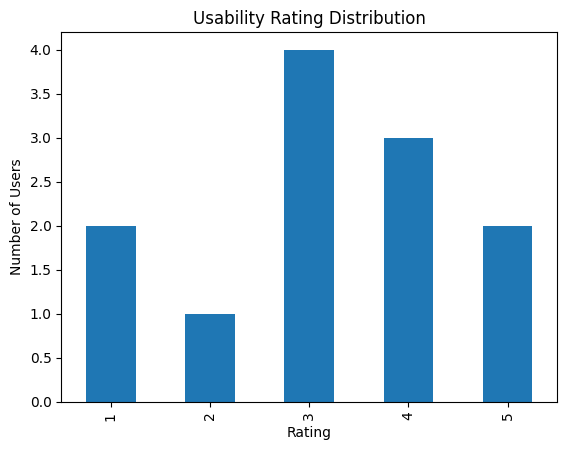

In [27]:
import matplotlib.pyplot as plt

df["Usability_Rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Usability Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Users")
plt.show()


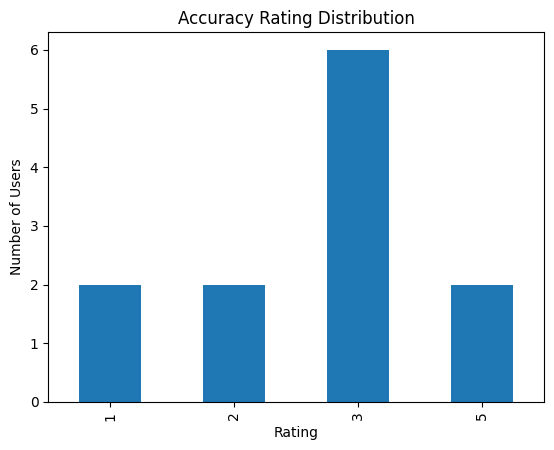

In [28]:
df["Accuracy_Rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Accuracy Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Users")
plt.show()


In [29]:
df["Suggestion"].value_counts().head(10)


,count
Suggestion,
good,5
make improvement very bad experience,1
Nothing,1
needs improvement,1
